## Install and Imports 

In [1]:
# pip install tensorflow scikit-learn nltk matplotlib

import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    GRU,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

## Download stopwords


In [2]:
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Load dataset


In [3]:
df = pd.read_csv("finall_dataset.csv")

df.head()

,Review,Sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df.shape

(50000, 2)

## Clean text

In [5]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z ]", "", text)

    text = re.sub(r"\s+", " ", text)

    words = text.split()

    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [6]:
# getting clean review  
df["Clean_Review"] = df["Review"].apply(clean_text)
df.head()

,Review,Sentiment,Clean_Review
0,One of the other reviewers has mentioned that ...,positive,one reviewers mentioned watching oz episode yo...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically theres family little boy jake thinks...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love time money visually stunni...


## Convert Sentiment Labels

In [7]:
df["Sentiment"] = df["Sentiment"].map({

    "positive": 1,
    "negative": 0,
    1: 1,
    0: 0

})

df.head()


,Review,Sentiment,Clean_Review
0,One of the other reviewers has mentioned that ...,1,one reviewers mentioned watching oz episode yo...
1,A wonderful little production. <br /><br />The...,1,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,1,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,0,basically theres family little boy jake thinks...
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,petter matteis love time money visually stunni...


## Features and labels

In [8]:
X = df["Clean_Review"]

y = df["Sentiment"]

## Tokenization


In [9]:
tokenizer = Tokenizer(num_words=10000)

tokenizer.fit_on_texts(X)

X_seq = tokenizer.texts_to_sequences(X)

## padding 

In [10]:
X_pad = pad_sequences(
    X_seq,
    maxlen=200
)

X_pad

array([[   0,    0,    0, ..., 1080, 3842,  387],
       [   0,    0,    0, ..., 1763,   14,  126],
       [   0,    0,    0, ...,   53,   11,  227],
       ...,
       [   0,    0,    0, ...,  253, 1499, 5840],
       [   0,    0,    0, ..., 2070, 4134,  593],
       [   0,    0,    0, ..., 4063,  662,    2]],
      shape=(50000, 200), dtype=int32)

## Train Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(

    X_pad,
    y,

    test_size=0.2,

    random_state=42

)

## LSTM

In [12]:
lstm_model = Sequential()

lstm_model.add(

    Embedding(

        input_dim=10000,

        output_dim=128,

        input_length=200

    )

)

lstm_model.add(

    LSTM(64)

)

lstm_model.add(

    Dropout(0.5)

)

lstm_model.add(

    Dense(1, activation='sigmoid')

)

lstm_model.compile(

    loss='binary_crossentropy',

    optimizer='adam',

    metrics=['accuracy']

)

lstm_model.summary()

c:\Users\user\OneDrive\Desktop\webscraping\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Training Lstm

In [13]:
early_stop = EarlyStopping(

    monitor='val_loss',

    patience=2,

    restore_best_weights=True

)

history_lstm = lstm_model.fit(

    X_train,
    y_train,

    epochs=5,

    batch_size=32,

    validation_data=(X_test, y_test),

    callbacks=[early_stop]

)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 248s 191ms/step - accuracy: 0.8483 - loss: 0.3573 - val_accuracy: 0.8783 - val_loss: 0.3002
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 214s 171ms/step - accuracy: 0.9106 - loss: 0.2315 - val_accuracy: 0.8880 - val_loss: 0.2831
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 257s 168ms/step - accuracy: 0.9319 - loss: 0.1810 - val_accuracy: 0.8783 - val_loss: 0.3155
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 241s 193ms/step - accuracy: 0.9516 - loss: 0.1339 - val_accuracy: 0.8763 - val_loss: 0.3333


## Evaluate 


In [14]:
lstm_pred = lstm_model.predict(X_test)

lstm_pred = (lstm_pred > 0.5).astype(int)

print(

    accuracy_score(
        y_test,
        lstm_pred
    )

)

print(

    classification_report(
        y_test,
        lstm_pred
    )

)

313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step
0.888
              precision    recall  f1-score   support

           0       0.90      0.87      0.88      4961
           1       0.87      0.91      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



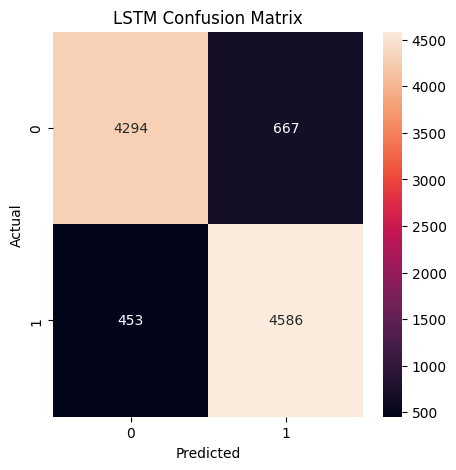

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, lstm_pred)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## GRU

In [16]:
gru_model = Sequential()

gru_model.add(

    Embedding(

        input_dim=10000,

        output_dim=128,


        input_length=200

    )

)

gru_model.add(

    GRU(64)

)

gru_model.add(

    Dropout(0.5)

)

gru_model.add(

    Dense(1, activation='sigmoid')

)

gru_model.compile(

    loss='binary_crossentropy',

    optimizer='adam',

    metrics=['accuracy']

)

gru_model.summary()

c:\Users\user\OneDrive\Desktop\webscraping\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

training

In [17]:
history_gru = gru_model.fit(

    X_train,
    y_train,

    epochs=5,

    batch_size=32,

    validation_data=(X_test, y_test),

    callbacks=[early_stop]

)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 227s 174ms/step - accuracy: 0.8432 - loss: 0.3576 - val_accuracy: 0.8890 - val_loss: 0.2677
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 247s 198ms/step - accuracy: 0.9180 - loss: 0.2171 - val_accuracy: 0.8919 - val_loss: 0.2738
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 226s 181ms/step - accuracy: 0.9483 - loss: 0.1467 - val_accuracy: 0.8872 - val_loss: 0.3164


In [18]:
gru_pred = gru_model.predict(X_test)

gru_pred = (gru_pred > 0.5).astype(int)

print(

    accuracy_score(
        y_test,
        gru_pred
    )

)

print(

    classification_report(
        y_test,
        gru_pred
    )

)

313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 77ms/step
0.889
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



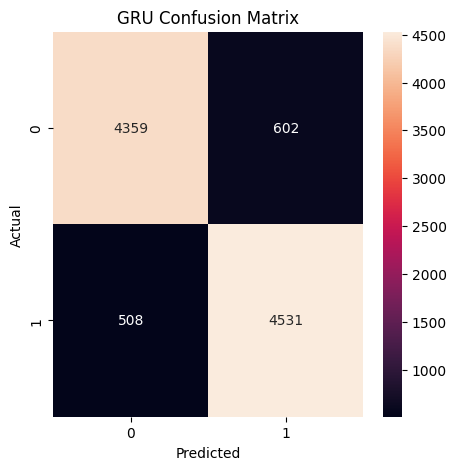

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, gru_pred)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("GRU Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Compare accuracy

In [20]:
lstm_acc = accuracy_score(
    y_test,
    lstm_pred
)

gru_acc = accuracy_score(
    y_test,
    gru_pred
)

print("LSTM Accuracy :", lstm_acc)

print("GRU Accuracy  :", gru_acc)

LSTM Accuracy : 0.888
GRU Accuracy  : 0.889


## accuracy graph


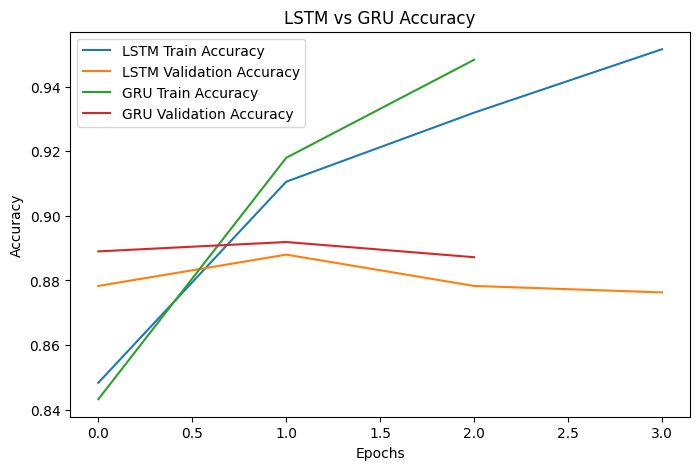

In [21]:
plt.figure(figsize=(8,5))

plt.plot(
    history_lstm.history['accuracy'],
    label='LSTM Train Accuracy'
)

plt.plot(
    history_lstm.history['val_accuracy'],
    label='LSTM Validation Accuracy'
)

plt.plot(
    history_gru.history['accuracy'],
    label='GRU Train Accuracy'
)

plt.plot(
    history_gru.history['val_accuracy'],
    label='GRU Validation Accuracy'
)

plt.title("LSTM vs GRU Accuracy")

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

## Scraped reviews

In [22]:
scraped_df = pd.read_csv(
    "bollywood_movies_reviews_2024_2026.csv"
)

scraped_df.head()

,Movie,Genre,Year,Review
0,Laapataa Ladies,Romantic-Comedy,2024,Anti Sandeep vanga movie frfr
1,Laapataa Ladies,Romantic-Comedy,2024,Refreshingly original in its pathos rather tha...
2,Laapataa Ladies,Romantic-Comedy,2024,Deepak😭\nPhool😭
3,Laapataa Ladies,Romantic-Comedy,2024,Highly recommends
4,Laapataa Ladies,Romantic-Comedy,2024,approx date. for the liberal indians of the ba...


In [23]:
#cleaning the scraped reviews
scraped_df["Clean_Review"] = scraped_df["Review"].apply(clean_text)

scraped_df.head()

,Movie,Genre,Year,Review,Clean_Review
0,Laapataa Ladies,Romantic-Comedy,2024,Anti Sandeep vanga movie frfr,anti sandeep vanga movie frfr
1,Laapataa Ladies,Romantic-Comedy,2024,Refreshingly original in its pathos rather tha...,refreshingly original pathos rather setting ch...
2,Laapataa Ladies,Romantic-Comedy,2024,Deepak😭\nPhool😭,deepakphool
3,Laapataa Ladies,Romantic-Comedy,2024,Highly recommends,highly recommends
4,Laapataa Ladies,Romantic-Comedy,2024,approx date. for the liberal indians of the ba...,approx date liberal indians bay lovely nonethe...


In [25]:
#convert reviews to numbers
scraped_sequences = tokenizer.texts_to_sequences(
    scraped_df["Clean_Review"]
)

In [29]:
#padding
scraped_padded = pad_sequences(
    scraped_sequences,
    maxlen=200
)

## Predict sentiment
Using the GRU model (it performed slightly better):

In [30]:
predictions = gru_model.predict(
    scraped_padded
)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step


In [32]:
# converting predictions to labels
scraped_df["Predicted_Sentiment"] = (
    predictions > 0.5
).astype(int)

In [33]:
scraped_df["Predicted_Sentiment"] = (
    scraped_df["Predicted_Sentiment"]
    .map({
        1: "Positive",
        0: "Negative"
    })
)

In [35]:
scraped_df[
    ["Movie", "Review", "Predicted_Sentiment"]
].head(5)

,Movie,Review,Predicted_Sentiment
0,Laapataa Ladies,Anti Sandeep vanga movie frfr,Negative
1,Laapataa Ladies,Refreshingly original in its pathos rather tha...,Positive
2,Laapataa Ladies,Deepak😭\nPhool😭,Negative
3,Laapataa Ladies,Highly recommends,Positive
4,Laapataa Ladies,approx date. for the liberal indians of the ba...,Positive
